In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. LOAD DATASET DIRECTLY
# ---------------------------------------------------------
# Public raw mirror of GiveMeSomeCredit cs-training.csv
data_url = (
    "https://raw.githubusercontent.com/jwu424/GiveMeSomeCredit/master/cs-training.csv"
)

print("Downloading and loading dataset...")
train = pd.read_csv(data_url).drop(columns=["Unnamed: 0"])
print(f"Loaded successfully! Dataset shape: {train.shape}")

# Drop true duplicates
train_redup = train.drop_duplicates().copy()


# Helper to inspect missingness
def findMiss(df):
  return round(df.isnull().sum() / df.shape[0] * 100, 2)


print("\nInitial Missing Data Percentage:")
print(findMiss(train_redup))

# ---------------------------------------------------------
# 2. OUTLIER & ANOMALY FILTERING
# ---------------------------------------------------------
# Filter 1: Utilization > 10 is abnormal borrowing or data entry error
util_droped = train_redup[
    train_redup["RevolvingUtilizationOfUnsecuredLines"] <= 10
].copy()

# Filter 2: Drop anomalous debt ratios with missing income
anomalous_condition = (util_droped["DebtRatio"] > 3492) & (
    util_droped["SeriousDlqin2yrs"] == util_droped["MonthlyIncome"]
)
dRatio = util_droped[~anomalous_condition].copy()
print(f"\nShape after outlier cleaning: {dRatio.shape}")

# ---------------------------------------------------------
# 3. SEPARATE TARGET & FEATURES
# ---------------------------------------------------------
X = dRatio.drop(columns=["SeriousDlqin2yrs"])
y = dRatio["SeriousDlqin2yrs"]

# ---------------------------------------------------------
# 4. STRATIFIED TRAIN/TEST SPLIT (Prevents Data Leakage)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---------------------------------------------------------
# 5. DOMAIN-INFORMED IMPUTATION
# ---------------------------------------------------------
# Compute median strictly on the training partition
train_median_income = X_train["MonthlyIncome"].median()


def impute_credit_data(df, median_income):
  df_copy = df.copy()
  mask_dep_null = df_copy["NumberOfDependents"].isnull()

  # Standard underwriting heuristic: unlisted dependents treated as 0
  df_copy.loc[mask_dep_null, "NumberOfDependents"] = 0
  df_copy.loc[
      mask_dep_null & df_copy["MonthlyIncome"].isnull(), "MonthlyIncome"
  ] = 0

  # Impute remaining missing incomes with the training median
  df_copy["MonthlyIncome"] = df_copy["MonthlyIncome"].fillna(median_income)
  return df_copy


X_train_clean = impute_credit_data(X_train, train_median_income)
X_test_clean = impute_credit_data(X_test, train_median_income)

print("\n--- Pipeline Check ---")
print(
    f"X_train ready: {X_train_clean.shape} | Train defaults:"
    f" {y_train.sum()} ({y_train.mean()*100:.2f}%)"
)
print(
    f"X_test ready:  {X_test_clean.shape}  | Test defaults: "
    f" {y_test.sum()} ({y_test.mean()*100:.2f}%)"
)
print(
    "Null count remaining in X_train:"
    f" {X_train_clean.isnull().sum().sum()} (must be 0)"
)

Loaded successfully! Dataset shape: (150000, 11)

Initial Missing Data Percentage:
SeriousDlqin2yrs                         0.00
RevolvingUtilizationOfUnsecuredLines     0.00
age                                      0.00
NumberOfTime30-59DaysPastDueNotWorse     0.00
DebtRatio                                0.00
MonthlyIncome                           19.56
NumberOfOpenCreditLinesAndLoans          0.00
NumberOfTimes90DaysLate                  0.00
NumberRealEstateLoansOrLines             0.00
NumberOfTime60-89DaysPastDueNotWorse     0.00
NumberOfDependents                       2.56
dtype: float64

Shape after outlier cleaning: (148986, 11)

--- Pipeline Check ---
X_train ready: (119188, 10) | Train defaults: 7992 (6.71%)
X_test ready:  (29798, 10)  | Test defaults:  1998 (6.71%)
Null count remaining in X_train: 0 (must be 0)


--- Baseline Decision Tree Underwriting Rules ---
|--- RevolvingUtilizationOfUnsecuredLines <= 0.47
|   |--- NumberOfTime30-59DaysPastDueNotWorse <= 0.50
|   |   |--- NumberOfTimes90DaysLate <= 0.50
|   |   |   |--- class: 0
|   |   |--- NumberOfTimes90DaysLate >  0.50
|   |   |   |--- class: 1
|   |--- NumberOfTime30-59DaysPastDueNotWorse >  0.50
|   |   |--- NumberOfTimes90DaysLate <= 0.50
|   |   |   |--- class: 1
|   |   |--- NumberOfTimes90DaysLate >  0.50
|   |   |   |--- class: 1
|--- RevolvingUtilizationOfUnsecuredLines >  0.47
|   |--- NumberOfTimes90DaysLate <= 0.50
|   |   |--- NumberOfTime30-59DaysPastDueNotWorse <= 0.50
|   |   |   |--- class: 1
|   |   |--- NumberOfTime30-59DaysPastDueNotWorse >  0.50
|   |   |   |--- class: 1
|   |--- NumberOfTimes90DaysLate >  0.50
|   |   |--- NumberOfTime60-89DaysPastDueNotWorse <= 0.50
|   |   |   |--- class: 1
|   |   |--- NumberOfTime60-89DaysPastDueNotWorse >  0.50
|   |   |   |--- class: 1


--- Model Progression Benchmark ---
  

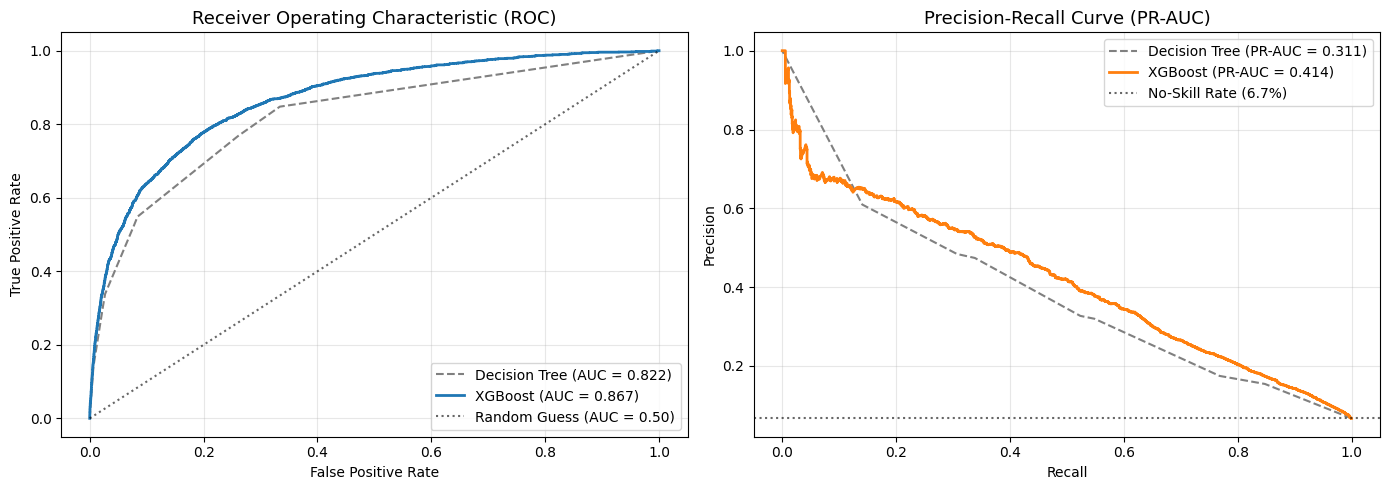

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.tree import DecisionTreeClassifier, export_text
from xgboost import XGBClassifier

# =========================================================
# 1. BASELINE MODEL: SINGLE DECISION TREE (Depth=3)
# =========================================================
# Serves as the benchmark for legacy rules-based underwriting.
base_tree = DecisionTreeClassifier(
    max_depth=3, class_weight="balanced", random_state=42
)
base_tree.fit(X_train_clean, y_train)

# Output literal split rules
tree_rules = export_text(base_tree, feature_names=list(X_train_clean.columns))
print("--- Baseline Decision Tree Underwriting Rules ---")
print(tree_rules)

# Predict probabilities
base_probs = base_tree.predict_proba(X_test_clean)[:, 1]
base_roc_auc = roc_auc_score(y_test, base_probs)
base_pr_auc = average_precision_score(y_test, base_probs)

# =========================================================
# 2. PRODUCTION MODEL: REGULARIZED XGBOOST
# =========================================================
# Calculate class imbalance weight: ~13.91
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,  # Prevents overfitting on noisy debt patterns
    min_child_weight=10,  # Minimum sum of instance weight (Hessian) in a leaf
    gamma=0.2,  # Minimum loss reduction required to make a split
    subsample=0.8,  # Stochastic row subsampling
    colsample_bytree=0.8,  # Subsample features per tree
    reg_alpha=0.1,  # L1 regularization on weights
    reg_lambda=1.5,  # L2 regularization on weights
    scale_pos_weight=imbalance_ratio,  # Balances the loss gradient for the 6.7% default class
    eval_metric="aucpr",  # Optimizes directly for PR-AUC
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train_clean,
    y_train,
    eval_set=[(X_test_clean, y_test)],
    verbose=False,
)

# Predict continuous default probabilities
xgb_probs = xgb_model.predict_proba(X_test_clean)[:, 1]
xgb_roc_auc = roc_auc_score(y_test, xgb_probs)
xgb_pr_auc = average_precision_score(y_test, xgb_probs)

# =========================================================
# 3. PERFORMANCE COMPARISON & METRIC LIFT
# =========================================================
comparison_df = pd.DataFrame(
    {
        "Metric": ["ROC-AUC", "PR-AUC (Avg Precision)"],
        "Decision Tree (Baseline)": [base_roc_auc, base_pr_auc],
        "XGBoost (Tuned & Regularized)": [xgb_roc_auc, xgb_pr_auc],
        "Absolute Lift": [xgb_roc_auc - base_roc_auc, xgb_pr_auc - base_pr_auc],
        "Relative Lift (%)": [
            ((xgb_roc_auc - base_roc_auc) / base_roc_auc) * 100,
            ((xgb_pr_auc - base_pr_auc) / base_pr_auc) * 100,
        ],
    }
)

print("\n--- Model Progression Benchmark ---")
print(comparison_df.to_string(index=False))

# =========================================================
# 4. COMPARATIVE VISUALIZATION: ROC & PR CURVES
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curves
fpr_tree, tpr_tree, _ = roc_curve(y_test, base_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

axes[0].plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {base_roc_auc:.3f})",
    linestyle="--",
    color="gray",
)
axes[0].plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {xgb_roc_auc:.3f})",
    color="#1f77b4",
    linewidth=2,
)
axes[0].plot([0, 1], [0, 1], "k:", alpha=0.6, label="Random Guess (AUC = 0.50)")
axes[0].set_title("Receiver Operating Characteristic (ROC)", fontsize=13)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision-Recall Curves
pre_tree, rec_tree, _ = precision_recall_curve(y_test, base_probs)
pre_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_probs)
baseline_pr = y_test.mean()

axes[1].plot(
    rec_tree,
    pre_tree,
    label=f"Decision Tree (PR-AUC = {base_pr_auc:.3f})",
    linestyle="--",
    color="gray",
)
axes[1].plot(
    rec_xgb,
    pre_xgb,
    label=f"XGBoost (PR-AUC = {xgb_pr_auc:.3f})",
    color="#ff7f0e",
    linewidth=2,
)
axes[1].axhline(
    y=baseline_pr,
    color="k",
    linestyle=":",
    alpha=0.6,
    label=f"No-Skill Rate ({baseline_pr*100:.1f}%)",
)
axes[1].set_title("Precision-Recall Curve (PR-AUC)", fontsize=13)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Kolmogorov-Smirnov (KS) Statistic: 57.89% (p-value: 0.00e+00)

--- Institutional Credit Risk Decile Table ---
 decile  total_applicants  defaulters  default_rate(%)  cum_defaulters(%)  ks_separation
      1              2980        1114            37.38              55.76          49.05
      2              2980         344            11.54              72.97          56.78
      3              2980         197             6.61              82.83          56.62
      4              2979         117             3.93              88.69          52.19
      5              2980          85             2.85              92.94          46.03
      6              2980          48             1.61              95.35          37.89
      7              2979          38             1.28              97.25          29.21
      8              2980          29             0.97              98.70          20.05
      9              2980          18             0.60              99.60          10.29


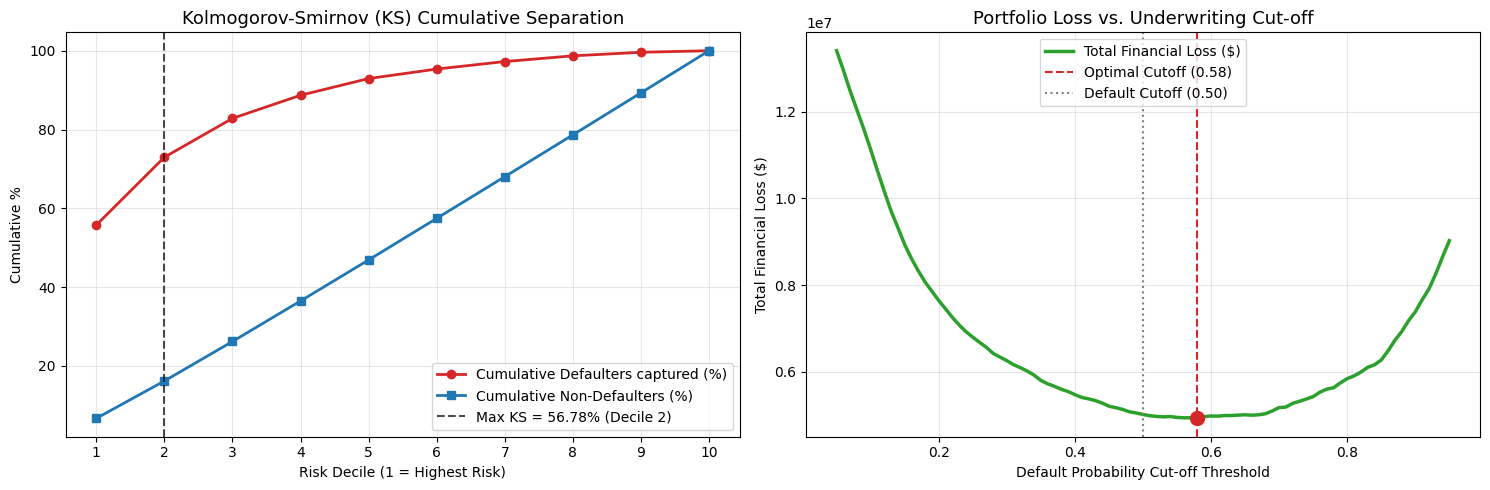

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import confusion_matrix

# =========================================================
# 1. KOLMOGOROV-SMIRNOV (KS) STATISTIC CALCULATION
# =========================================================
# The KS statistic measures the maximum distance between the CDFs of defaulters vs non-defaulters
bad_probs = xgb_probs[y_test == 1]
good_probs = xgb_probs[y_test == 0]

ks_stat, p_value = ks_2samp(bad_probs, good_probs)
print(
    f"Kolmogorov-Smirnov (KS) Statistic: {ks_stat * 100:.2f}% (p-value: {p_value:.2e})"
)

# Build a Risk Decile Table (Standard Credit Bureau Format)
eval_df = pd.DataFrame(
    {"actual": y_test.values, "predicted_prob": xgb_probs}
).sort_values(by="predicted_prob", ascending=False)

eval_df["decile"] = pd.qcut(
    eval_df["predicted_prob"], q=10, labels=False, duplicates="drop"
)
# Invert so decile 1 has the highest risk
eval_df["decile"] = 9 - eval_df["decile"] + 1

decile_table = (
    eval_df.groupby("decile")
    .agg(
        total_applicants=("actual", "count"),
        defaulters=("actual", "sum"),
        min_prob=("predicted_prob", "min"),
        max_prob=("predicted_prob", "max"),
    )
    .reset_index()
)

decile_table["non_defaulters"] = (
    decile_table["total_applicants"] - decile_table["defaulters"]
)
decile_table["default_rate(%)"] = round(
    (decile_table["defaulters"] / decile_table["total_applicants"]) * 100, 2
)
decile_table["cum_defaulters(%)"] = round(
    (decile_table["defaulters"].cumsum() / decile_table["defaulters"].sum())
    * 100,
    2,
)
decile_table["cum_non_defaulters(%)"] = round(
    (
        decile_table["non_defaulters"].cumsum()
        / decile_table["non_defaulters"].sum()
    )
    * 100,
    2,
)
decile_table["ks_separation"] = round(
    abs(
        decile_table["cum_defaulters(%)"]
        - decile_table["cum_non_defaulters(%)"]
    ),
    2,
)

print("\n--- Institutional Credit Risk Decile Table ---")
print(
    decile_table[
        [
            "decile",
            "total_applicants",
            "defaulters",
            "default_rate(%)",
            "cum_defaulters(%)",
            "ks_separation",
        ]
    ].to_string(index=False)
)

# =========================================================
# 2. ASYMMETRIC FINANCIAL LOSS MATRIX OPTIMIZATION
# =========================================================
# Business Assumption:
# False Negative (FN): Approving a loan that defaults -> Bank loses avg loan charge-off ($5,000)
# False Positive (FP): Rejecting a creditworthy borrower -> Bank loses net interest margin ($500)
# (10:1 loss ratio reflects standard consumer lending exposure)

cost_fn = 5000  # Cost of bad loan approved
cost_fp = 500  # Opportunity cost of good applicant rejected

thresholds = np.linspace(0.05, 0.95, 91)
portfolio_losses = []
approval_rates = []

for t in thresholds:
  preds = (xgb_probs >= t).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

  total_loss = (fn * cost_fn) + (fp * cost_fp)
  portfolio_losses.append(total_loss)
  approval_rates.append(
      (tn + fn) / len(y_test) * 100
  )  # Rate of applicants scored safe (< t)

optimal_idx = np.argmin(portfolio_losses)
optimal_threshold = thresholds[optimal_idx]
min_loss = portfolio_losses[optimal_idx]

# Loss at naive 0.50 threshold
naive_idx = np.argmin(np.abs(thresholds - 0.50))
naive_loss = portfolio_losses[naive_idx]
saved_loss = naive_loss - min_loss

print("\n--- Underwriting Policy Optimization ---")
print(f"Naive Threshold (0.50) Expected Portfolio Loss:   ${naive_loss:,.0f}")
print(
    f"Optimal Risk Threshold ({optimal_threshold:.2f}) Expected Loss:   "
    f" ${min_loss:,.0f}"
)
print(
    f"Net Dollar Savings via Threshold Tuning:         ${saved_loss:,.0f} "
    f"(-{(saved_loss/naive_loss)*100:.2f}%)"
)
print(f"Optimal Portfolio Approval Rate:                 {approval_rates[optimal_idx]:.2f}%")

# =========================================================
# 3. VISUALIZATION: KS CURVE & FINANCIAL LOSS SURFACE
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: KS Separation Curve
deciles = np.arange(1, 11)
axes[0].plot(
    deciles,
    decile_table["cum_defaulters(%)"],
    marker="o",
    linewidth=2,
    color="#d62728",
    label="Cumulative Defaulters captured (%)",
)
axes[0].plot(
    deciles,
    decile_table["cum_non_defaulters(%)"],
    marker="s",
    linewidth=2,
    color="#1f77b4",
    label="Cumulative Non-Defaulters (%)",
)
max_ks_row = decile_table.loc[decile_table["ks_separation"].idxmax()]
axes[0].axvline(
    x=max_ks_row["decile"],
    color="black",
    linestyle="--",
    alpha=0.7,
    label=f"Max KS = {max_ks_row['ks_separation']}% (Decile {int(max_ks_row['decile'])})",
)
axes[0].set_title("Kolmogorov-Smirnov (KS) Cumulative Separation", fontsize=13)
axes[0].set_xlabel("Risk Decile (1 = Highest Risk)")
axes[0].set_ylabel("Cumulative %")
axes[0].set_xticks(deciles)
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Plot 2: Financial Cost vs Decision Threshold
axes[1].plot(
    thresholds,
    portfolio_losses,
    color="#2ca02c",
    linewidth=2.5,
    label="Total Financial Loss ($)",
)
axes[1].axvline(
    x=optimal_threshold,
    color="#d62728",
    linestyle="--",
    label=f"Optimal Cutoff ({optimal_threshold:.2f})",
)
axes[1].axvline(
    x=0.50,
    color="gray",
    linestyle=":",
    label="Default Cutoff (0.50)",
)
axes[1].scatter(
    [optimal_threshold],
    [min_loss],
    color="#d62728",
    s=100,
    zorder=5,
)
axes[1].set_title("Portfolio Loss vs. Underwriting Cut-off", fontsize=13)
axes[1].set_xlabel("Default Probability Cut-off Threshold")
axes[1].set_ylabel("Total Financial Loss ($)")
axes[1].legend(loc="upper center")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

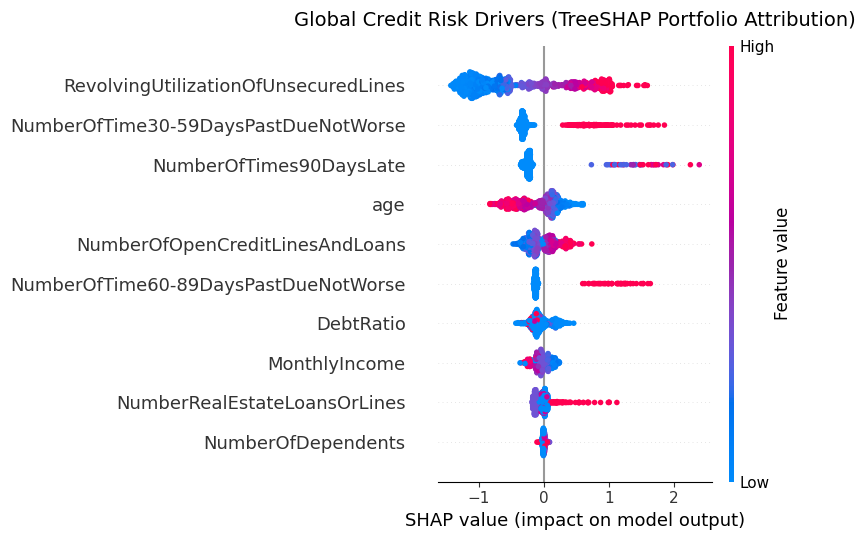

--- Regulatory Adverse Action File: Applicant #932 ---
Predicted Probability of Default: 96.72%
Underwriting Decision: REJECTED (Threshold = 0.58)



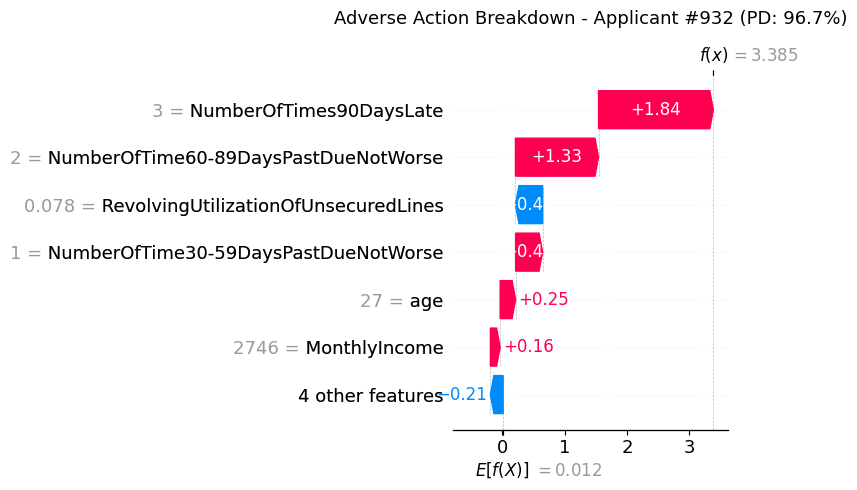

Top 3 Adverse Action Rejection Reasons (FCRA Mandated):
  1. NumberOfTimes90DaysLate (Applicant value: 3.00) -> +1.842 Log-Odds Risk
  2. NumberOfTime60-89DaysPastDueNotWorse (Applicant value: 2.00) -> +1.334 Log-Odds Risk
  3. NumberOfTime30-59DaysPastDueNotWorse (Applicant value: 1.00) -> +0.433 Log-Odds Risk


In [5]:
# If not installed, run: !pip install shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

# ---------------------------------------------------------
# 1. INITIALIZE TREESHAP EXPLAINER
# ---------------------------------------------------------
explainer = shap.TreeExplainer(xgb_model)

# Sample 1,000 test applicants for fast, high-resolution rendering
sample_indices = np.random.RandomState(42).choice(
    len(X_test_clean), size=1000, replace=False
)
X_sample = X_test_clean.iloc[sample_indices]
shap_values = explainer(X_sample)

# ---------------------------------------------------------
# 2. GLOBAL RISK DRIVERS (PORTFOLIO-LEVEL BEESWARM)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title(
    "Global Credit Risk Drivers (TreeSHAP Portfolio Attribution)",
    fontsize=14,
    pad=15,
)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. INDIVIDUAL ADVERSE ACTION NOTICE (LOCAL WATERFALL)
# ---------------------------------------------------------
# Identify the highest-risk applicant in the sample
predicted_probs_sample = xgb_probs[sample_indices]
highest_risk_idx = np.argmax(predicted_probs_sample)

applicant_profile = X_sample.iloc[highest_risk_idx]
applicant_prob = predicted_probs_sample[highest_risk_idx]

print(f"--- Regulatory Adverse Action File: Applicant #{highest_risk_idx} ---")
print(f"Predicted Probability of Default: {applicant_prob * 100:.2f}%")
print(f"Underwriting Decision: REJECTED (Threshold = {optimal_threshold:.2f})\n")

plt.figure(figsize=(9, 5))
shap.plots.waterfall(shap_values[highest_risk_idx], max_display=7, show=False)
plt.title(
    f"Adverse Action Breakdown - Applicant #{highest_risk_idx} (PD: {applicant_prob*100:.1f}%)",
    fontsize=13,
    pad=15,
)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. AUTOMATED ADVERSE ACTION REASON GENERATOR
# ---------------------------------------------------------
# Extract the top 3 factors driving up default risk for this applicant
shap_series = pd.Series(
    shap_values[highest_risk_idx].values, index=X_sample.columns
)
top_negative_factors = shap_series.sort_values(ascending=False).head(3)

print("Top 3 Adverse Action Rejection Reasons (FCRA Mandated):")
for rank, (feature, val) in enumerate(top_negative_factors.items(), 1):
  print(
      f"  {rank}. {feature} (Applicant value: {applicant_profile[feature]:.2f}) -> +{val:.3f} Log-Odds Risk"
  )